# DeepSurv using `PyCox`  

Goal of this notebook is to: 
- Show how to Process Data into the format that `PyCox` wants  
- Building a Neural Net 
- Training a Model  
- Prediction  
- Evaluation  

See 05_DeepSurvCV.ipynb to see how to implement the steps using Cross-Validation

Some of the code for this notebook uses data and code from `cox-ph.ipynb` Notebook [Tutorial](https://github.com/havakv/pycox/blob/master/examples/cox-ph.ipynb). 

## 0. Preliminaries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn_pandas import DataFrameMapper

import torch
import torchtuples as tt

from sksurv.datasets import load_breast_cancer
from sksurv.preprocessing import OneHotEncoder

from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

Define Random Seeds 

In [ ]:
np.random.seed(1234)
_ = torch.manual_seed(123)

## 1. Data Processing 

Load Data

In [7]:
X, y = load_breast_cancer()
Xt = OneHotEncoder().fit_transform(X)
Xt.head(5)

,X200726_at,X200965_s_at,X201068_s_at,X201091_s_at,X201288_at,X201368_at,X201663_s_at,X201664_at,X202239_at,X202240_at,...,X221816_s_at,X221882_s_at,X221916_at,X221928_at,age,er=positive,grade=intermediate,grade=poorly differentiated,grade=unkown,size
0,10.926361,8.962608,11.630078,10.964107,11.518305,12.038527,9.623518,9.814798,10.016732,7.847383,...,10.132635,10.926365,6.477749,5.991885,57.0,0.0,0.0,1.0,0.0,3.0
1,12.242090,9.531718,12.626106,11.594716,12.317659,10.776911,10.604577,10.704329,10.161838,8.744875,...,10.213467,9.555092,4.968050,7.051130,57.0,1.0,0.0,1.0,0.0,3.0
2,11.661716,10.238680,12.572919,9.166088,11.698658,11.353333,9.384927,10.161654,10.032721,8.125487,...,10.164514,9.308048,4.283777,6.828986,48.0,0.0,0.0,1.0,0.0,2.5
3,12.174021,9.819279,12.109888,9.086937,13.132617,11.859394,8.400839,8.670721,10.727427,8.650810,...,10.660092,10.208241,5.713404,6.927251,42.0,1.0,0.0,1.0,0.0,1.8
4,11.484011,11.489233,11.779285,8.887616,10.429663,11.401139,7.741092,8.642018,9.556686,8.478862,...,11.570330,10.931843,5.817265,6.655448,46.0,1.0,1.0,0.0,0.0,3.0


Let's see what our feature matrix dimensions are (this will be important later)

In [8]:
Xt.shape

(198, 82)

### Feature Transformations [IMPT]

From `Xt.shape`, we have 82 variables and 198 samples, with `er=positive` and `grade=...` being binary/categorical variables. 
Generally, for most neural nets & penalized cox methods, you standardize your continuous features such that columns have a mean of 0 and variance of 1

Since we have a "lot" of variables and we don't want to type all of them out, let's identify the columns that we DO NOT want to standardize. 


In [ ]:
Xt_col_names = Xt.columns.tolist()
print(Xt_col_names)

['X200726_at', 'X200965_s_at', 'X201068_s_at', 'X201091_s_at', 'X201288_at', 'X201368_at', 'X201663_s_at', 'X201664_at', 'X202239_at', 'X202240_at', 'X202418_at', 'X202687_s_at', 'X203306_s_at', 'X203391_at', 'X204014_at', 'X204015_s_at', 'X204073_s_at', 'X204218_at', 'X204540_at', 'X204631_at', 'X204740_at', 'X204768_s_at', 'X204888_s_at', 'X205034_at', 'X205848_at', 'X206295_at', 'X207118_s_at', 'X208180_s_at', 'X208683_at', 'X209500_x_at', 'X209524_at', 'X209835_x_at', 'X209862_s_at', 'X210028_s_at', 'X210314_x_at', 'X210593_at', 'X211040_x_at', 'X211382_s_at', 'X211762_s_at', 'X211779_x_at', 'X212014_x_at', 'X212567_s_at', 'X214806_at', 'X214915_at', 'X214919_s_at', 'X215510_at', 'X215633_x_at', 'X216010_x_at', 'X216103_at', 'X216693_x_at', 'X217019_at', 'X217102_at', 'X217404_s_at', 'X217471_at', 'X217767_at', 'X217771_at', 'X217815_at', 'X218430_s_at', 'X218478_s_at', 'X218533_s_at', 'X218782_s_at', 'X218883_s_at', 'X218914_at', 'X219340_s_at', 'X219510_at', 'X219588_s_at', 'X219

The columns we DO NOT want to standardize are `er=positive`, `grade=intermediate`, `grade=poorly differentiated`, `grade=unkown`. 

In [12]:
cols_leave = ['er=positive', 'grade=intermediate', 'grade=poorly differentiated', 'grade=unkown']
cols_standardize = [col for col in Xt_col_names if col not in cols_leave]

# Check the cols_standardize
print(cols_standardize)

# Define the DataFrameMapper which takes any feature matrix and standardizes the features in cols_standardize and leaves the features in cols_leave alone
standardize = [([col], StandardScaler()) for col in cols_standardize]
leave = [(col, None) for col in cols_leave]

x_mapper = DataFrameMapper(standardize + leave)

['X200726_at', 'X200965_s_at', 'X201068_s_at', 'X201091_s_at', 'X201288_at', 'X201368_at', 'X201663_s_at', 'X201664_at', 'X202239_at', 'X202240_at', 'X202418_at', 'X202687_s_at', 'X203306_s_at', 'X203391_at', 'X204014_at', 'X204015_s_at', 'X204073_s_at', 'X204218_at', 'X204540_at', 'X204631_at', 'X204740_at', 'X204768_s_at', 'X204888_s_at', 'X205034_at', 'X205848_at', 'X206295_at', 'X207118_s_at', 'X208180_s_at', 'X208683_at', 'X209500_x_at', 'X209524_at', 'X209835_x_at', 'X209862_s_at', 'X210028_s_at', 'X210314_x_at', 'X210593_at', 'X211040_x_at', 'X211382_s_at', 'X211762_s_at', 'X211779_x_at', 'X212014_x_at', 'X212567_s_at', 'X214806_at', 'X214915_at', 'X214919_s_at', 'X215510_at', 'X215633_x_at', 'X216010_x_at', 'X216103_at', 'X216693_x_at', 'X217019_at', 'X217102_at', 'X217404_s_at', 'X217471_at', 'X217767_at', 'X217771_at', 'X217815_at', 'X218430_s_at', 'X218478_s_at', 'X218533_s_at', 'X218782_s_at', 'X218883_s_at', 'X218914_at', 'X219340_s_at', 'X219510_at', 'X219588_s_at', 'X219

### Test-Train-Validation Split  

In [37]:
from sklearn.model_selection import StratifiedKFold, train_test_split

# Create the Fold Indcies 
event_indicator = y["e.tdm"]
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123) # Create the stratified folds 

# Stratifies BASED on the event_indicator so you don't get folds with 0 events, which would be problematic
# next() gives you the FIRST fold (great for debugging)
trainval_index, test_index = next(kf.split(Xt, event_indicator)) 

# Split into TrainVal + Test
X_trainval, X_test = Xt.iloc[trainval_index], Xt.iloc[test_index]
y_trainval, y_test = y[trainval_index], y[test_index]

# Split into Train + Validation
X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, 
            y_trainval, 
            test_size=0.2, 
            random_state=123)

# TRANSFORM features 
X_train_sc = x_mapper.fit_transform(X_train).astype('float32')
X_val_sc = x_mapper.transform(X_val).astype('float32')
X_test_sc = x_mapper.transform(X_test).astype('float32')

# "TRANSFORM" survival targets into tuples (duration, event)
def get_target(y_struct, event_field="e.tdm", time_field="t.tdm"):
    events = y_struct[event_field].astype(np.int64)      # True/False -> 1/0
    durations = y_struct[time_field].astype(np.float32)  # float32 is fine
    return (durations, events)

# Build targets as tuples (durations, events)
y_train_tup = get_target(y_train)   # (durations_train, events_train)
y_val_tup   = get_target(y_val)
y_test_tup  = get_target(y_test)

val = (X_val_sc, y_val_tup)

## 2. Building the Neural Net

In [31]:
in_features = X_train_sc.shape[1]
num_nodes = [32, 32]
out_features = 1
batch_norm = True
dropout = 0.1
output_bias = False

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm,
                              dropout, output_bias=output_bias)

## 3. Training the Model 

In [39]:
# Define key parameters 
lr = 0.0001 # <- learning rate; I manually set this since fast learning rates can lead to overfitting
model = CoxPH(net, tt.optim.Adam) # <- Use Adam optimizer (pretty standard)
model.optimizer.set_lr(lr)
epochs = 100 
batch_size = 64 # <- batch is a small subset of training data used to compute one gradient update at a time 
callbacks = [tt.callbacks.EarlyStopping()] # You can set your epochs as high as you need to, but essentially your validation metrics stop improving/show marginal improvements
verbose = True 

# train the model
log = model.fit(X_train_sc, y_train_tup, batch_size, epochs, callbacks, verbose, val_data=val, val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 3.7791,	val_loss: 3.4968
1:	[0s / 0s],		train_loss: 3.7952,	val_loss: 3.4954
2:	[0s / 0s],		train_loss: 3.6893,	val_loss: 3.4884
3:	[0s / 0s],		train_loss: 3.7228,	val_loss: 3.4803
4:	[0s / 0s],		train_loss: 3.7494,	val_loss: 3.4759
5:	[0s / 0s],		train_loss: 3.7481,	val_loss: 3.4716
6:	[0s / 0s],		train_loss: 3.7238,	val_loss: 3.4671
7:	[0s / 0s],		train_loss: 3.7318,	val_loss: 3.4616
8:	[0s / 0s],		train_loss: 3.7722,	val_loss: 3.4590
9:	[0s / 0s],		train_loss: 3.7845,	val_loss: 3.4543
10:	[0s / 0s],		train_loss: 3.7652,	val_loss: 3.4516
11:	[0s / 0s],		train_loss: 3.7016,	val_loss: 3.4484
12:	[0s / 0s],		train_loss: 3.7042,	val_loss: 3.4462
13:	[0s / 0s],		train_loss: 3.6587,	val_loss: 3.4462
14:	[0s / 0s],		train_loss: 3.8338,	val_loss: 3.4443
15:	[0s / 0s],		train_loss: 3.6979,	val_loss: 3.4420
16:	[0s / 0s],		train_loss: 3.7063,	val_loss: 3.4446
17:	[0s / 0s],		train_loss: 3.6551,	val_loss: 3.4424
18:	[0s / 0s],		train_loss: 3.6613,	val_loss: 3.4411
19:

We can visualize the losses using a plot

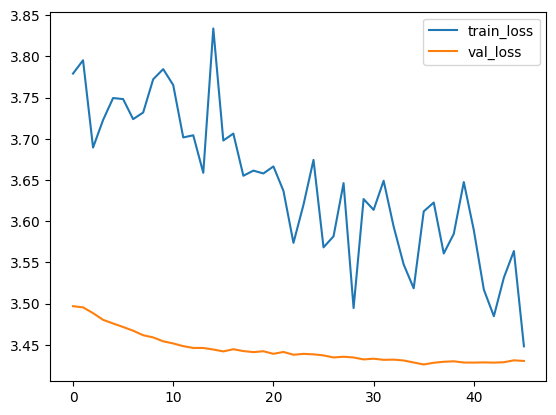

In [40]:
_ = log.plot()

notice that the validation loss stops improving around epoch 45

## 4. Prediction

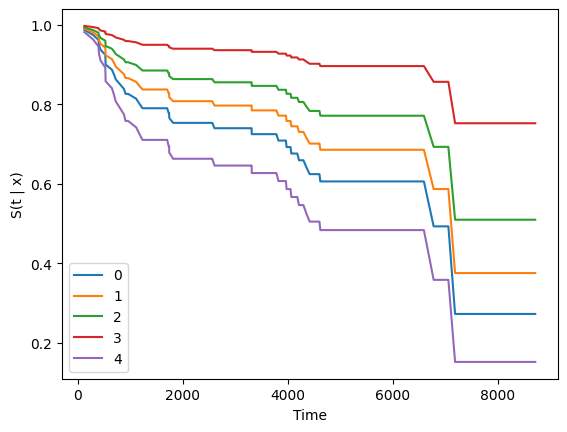

In [ ]:
_ = model.compute_baseline_hazards()
surv = model.predict_surv_df(X_test_sc)

# We can visualize the predicted survival curves for the first 5 subjects in our test data
surv.iloc[:, :5].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

## 5. Evaluation

Use `EvalSurv` to evaluate your model. You must complete the set up your baseline hazards and survival prediction in section 4 (see above) before you evaluate your model. 

In [43]:
durations_test, events_test = y_test_tup
ev = EvalSurv(surv, durations_test, events_test, censor_surv='km')

### 5.1 C-index

In [50]:
c_index = ev.concordance_td()
print(f"C-index = {c_index}")

C-index = 0.6218487394957983


### 5.2 Brier Score & Integrated Brier Score  

Brier Scores are a little more work to compute since you need to establish the time points you want to evaluate over, which is an extra line of code (sometimes steps if you are not working with PyCox). 

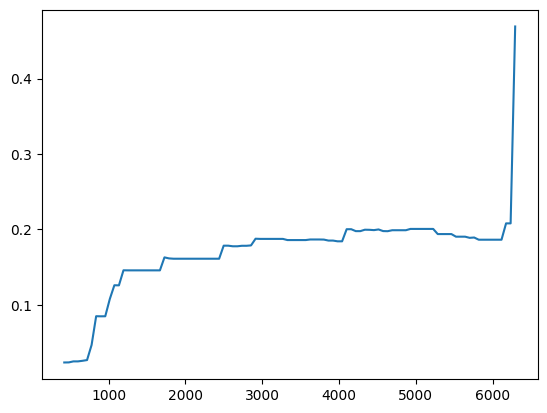

In [45]:
time_grid = np.linspace(durations_test.min(), durations_test.max(), 100)
_ = ev.brier_score(time_grid).plot()

A Note about Integrated Brier Scores: The function in PyCox relies on scipy integration, which is broken in PyCox so `ev.integrated_brier_score(time_grid)` won't work unless you run the following command: 

In [47]:
## MUST RUN THIS TO AVOID ISSUES WITH SCIPY INTEGRATE
import scipy.integrate as integ

# Provide a backwards-compat alias for pycox
if not hasattr(integ, "simps") and hasattr(integ, "simpson"):
    def simps(y, x, **kwargs):
        return integ.simpson(y, x=x, **kwargs)
    integ.simps = simps

In [51]:
ibs = ev.integrated_brier_score(time_grid)
print(f"Integrated Brier Score = {ibs}")

Integrated Brier Score = 0.1682523252588819
